In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import scipy.optimize as spyo
import matplotlib.pyplot as plt
url="https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
SP500=pd.read_html(url,storage_options={"User-Agent":"Mozzilla/5.0"})[0]
Companies=SP500['Symbol'].str.replace('.','-').tolist()
RealisationMatrix=yf.download(Companies,period='5y')['Close']

[*********************100%***********************]  503 of 503 completed


In [3]:
RealisationMatrix.head(5)

Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2021-07-26,145.010956,145.228302,98.041351,142.000000,108.444344,36.809280,293.632812,620.799988,150.589355,50.756691,...,28.119905,100.912094,58.238461,48.659298,116.823418,261.989990,112.405502,148.434525,545.309998,189.847305
2021-07-27,144.721390,143.064392,98.182854,141.580002,108.707458,36.638119,294.470520,618.280029,149.385773,51.112782,...,28.274059,97.062103,59.218906,48.118458,116.701012,251.729996,114.253899,151.400436,540.179993,190.839905
2021-07-28,146.178772,141.319550,98.673943,143.300003,109.351677,36.191200,291.174988,620.919983,150.717987,50.930401,...,27.884624,98.822655,58.570965,48.442966,115.740685,258.609985,111.640663,151.140106,545.739990,192.163422
2021-07-29,147.346542,141.962875,98.940285,143.470001,109.868843,36.609592,293.052856,621.700012,153.014969,51.764187,...,28.257841,96.501091,58.647701,49.033733,117.746094,255.279999,118.651764,151.307465,548.099976,192.966965
2021-07-30,147.887009,142.177307,96.801170,144.009995,109.769051,37.085041,292.436035,621.630005,153.823563,51.868416,...,27.365391,95.117775,58.187321,47.902122,118.489906,247.259995,119.635139,151.939682,552.479980,191.624573


In [4]:
#Denoising Matrix

#Dropping incomplete columns(companies) and converting data into a daily returns matrix.
Clean=RealisationMatrix.dropna(axis=1)

#Log taken for time additivity and symmetry. Making returns behave more like the normal distribution.
Returns=np.log(Clean/Clean.shift(1)).dropna()

#Splitting data in order to train and test model.
split=int(len(Returns)*0.8)
Returns_train=Returns.iloc[:split]
Returns_test=Returns.iloc[split:]

#Standardising data as required for RMT.
StandardizedReturns_train=(Returns_train-Returns_train.mean())/Returns_train.std()
X=StandardizedReturns_train.to_numpy()
T,N=X.shape

#Empirical Correlation Matrix
E=1/T * np.dot(X.T,X)
Evals,Evecs=np.linalg.eigh(E)

#Marchenko-Pastur Bound (upper)
lambdaplus=(1+np.sqrt(N/T))**2

#Treating eigenvalues lying in MP bounds as noise, and replacing such values by their mean.
signal=Evals>lambdaplus
mean_noise=np.mean(Evals[~signal])
EvalsClean=Evals.copy()
EvalsClean[~signal]=mean_noise

#Reconstructing denoised matrix using eigenvalue decompostion, and renormalising
EClean=Evecs@np.diag(EvalsClean)@Evecs.T 
Variances=np.diag(EClean)
EClean=np.outer(1/np.sqrt(Variances),1/np.sqrt(Variances))*EClean 

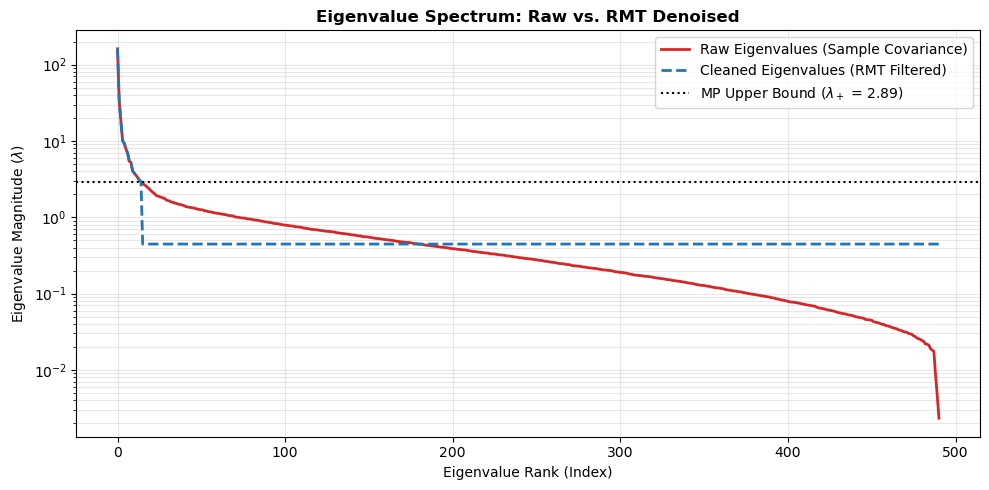

In [5]:
idx=np.argsort(Evals)[::-1]
evals_raw_sorted=Evals[idx]
evals_clean_sorted=EvalsClean[idx]
plt.plot(evals_raw_sorted,label='Raw Eigenvalues (Sample Covariance)',linewidth=2,)
plt.plot(evals_clean_sorted,label='Cleaned Eigenvalues (RMT Filtered)',linestyle='--',linewidth=2,)
plt.axhline(y=lambdaplus,color='black',linewidth=1.5,
            label=f'MP Upper Bound ($\lambda_+$ = {lambdaplus:.2f})')
plt.title('Eigenvalue Spectrum: Raw vs. RMT Denoised',fontsize=12,fontweight='bold')
plt.xlabel('Eigenvalue Rank (Index)',fontsize=10)
plt.ylabel('Eigenvalue Magnitude ($\lambda$)',fontsize=10)
plt.yscale('log')
plt.legend(loc='upper right')
plt.grid(True,which='both',alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
#Optimising portofolios (w) using the Sharpe Ratio for both CLean and Raw Covariance Matricies

#Sharpe Ratio as function of w
def sharperatio(w,mu,Sigma,rf=0.04):
    numerator=np.dot(w,mu)-rf #Returns
    denominator=np.sqrt(np.dot(w,np.dot(Sigma,w))) #Risk
    sharpe=numerator/denominator
    return -sharpe #Negative to convert maximisation to minimisation for SciPy.optimize.minimize
    
#Annual daily assest standard devitation and annual mean returns, scaled accordingly with time 
SD_yearly=Returns_train.std().to_numpy()*np.sqrt(252)
mu_yearly=Returns_train.mean().to_numpy()*252

#Converting correlation matrcies to covariance matricies
CleanSIGMA=np.diag(SD_yearly)@EClean@np.diag(SD_yearly)
RawSIGMA=np.diag(SD_yearly)@E@np.diag(SD_yearly)

#Initial guess (can be optimised)
initial=np.ones(N)/N 

#Bounds and constraints placed upon portfolio (w)
bounds=[(0,1) for _ in range(N)]
constraints= {'type':'eq','fun':lambda w:np.sum(w)-1}

#Minimising Sharpe Ratio with corresponding clean and raw data
optimise_clean=spyo.minimize(fun=sharperatio,x0=initial,args=(mu_yearly,CleanSIGMA),
                                method='SLSQP',bounds=bounds,constraints=constraints)
optimise_raw=spyo.minimize(fun=sharperatio,x0=initial,args=(mu_yearly,RawSIGMA),
                              method='SLSQP',bounds=bounds,constraints=constraints)
wclean=optimise_clean.x
wraw=optimise_raw.x
#Computing Sharpe Ratio on out of sample data
test_returns_matrix=Returns_test.to_numpy()
daily_ret_clean=test_returns_matrix@wclean
daily_ret_raw=test_returns_matrix@wraw
rf_daily=0.04/252 #Annual risk free rate to daily
sharpe_out_clean=(np.mean(daily_ret_clean)-rf_daily)/np.std(daily_ret_clean)*np.sqrt(252)
sharpe_out_raw=(np.mean(daily_ret_raw)-rf_daily)/np.std(daily_ret_raw)*np.sqrt(252)

In [7]:
total_growth_clean=np.prod(1+daily_ret_clean)-1
total_growth_raw=np.prod(1+daily_ret_raw)-1
growth_improvement=((total_growth_clean-total_growth_raw)/abs(total_growth_raw))*100
print(f"Clean Portfolio Cumulative Return: {total_growth_clean * 100:.2f}%")
print(f"Raw Portfolio Cumulative Return: {total_growth_raw * 100:.2f}%")
print(f"Growth Improvement: {growth_improvement:.2f}%")

Clean Portfolio Cumulative Return: 20.52%
Raw Portfolio Cumulative Return: 17.68%
Growth Improvement: 16.09%


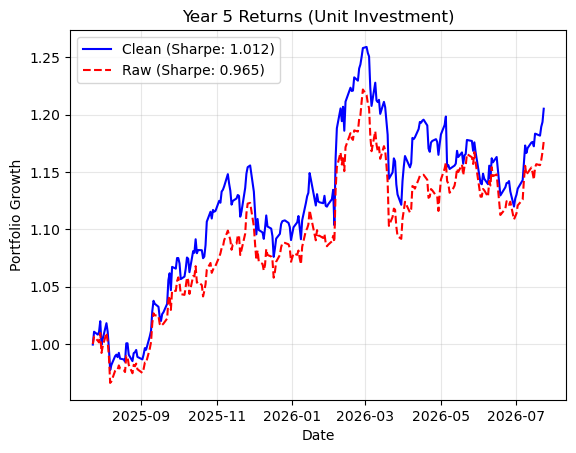

In [8]:
growth_clean=(1+daily_ret_clean).cumprod()
growth_raw=(1+daily_ret_raw).cumprod()
plt.plot(Returns_test.index,growth_clean,label=f'Clean (Sharpe: {sharpe_out_clean:.3f})',color='blue')
plt.plot(Returns_test.index, growth_raw, label=f'Raw (Sharpe: {sharpe_out_raw:.3f})',color='red',
         linestyle='--')
plt.title('Year 5 Returns (Unit Investment)')
plt.xlabel('Date')
plt.ylabel('Portfolio Growth')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()